# Estimasi Efek Kausal Program Promosi terhadap Pendapatan Bersih Perusahaan

Notebook ini menghasilkan seluruh angka, tabel, dan gambar pada **Bab 4** tesis, dengan alur yang sama seperti Bab 3:

| Bagian | Isi | Bab tesis |
|---|---|---|
| 1 | Pengaturan dan pustaka | Bab 3.7 |
| 2 | Membaca data dan definisi variabel | Bab 3.2–3.3 |
| 3 | Gambaran umum pendapatan dan diskon | Bab 4.1 |
| 4 | Pola pemberian program promosi (Gambar 4.1) | Bab 4.2 |
| 5 | Fungsi perhitungan: karakteristik pelanggan, cara konvensional, cara terkoreksi | Bab 3.3–3.5 |
| 6 | Ilustrasi promosi #8 (Tabel 4.1, Gambar 4.2) | Bab 4.3 |
| 7 | Hasil 30 program promosi (Tabel 4.2, Gambar 4.3) | Bab 4.4 |
| 8 | Efek rata-rata gabungan (Gambar 4.4) | Bab 4.5 |
| 9 | Tambahan biaya diskon (Tabel 4.3, Gambar 4.5) | Bab 4.6 |
| 10 | Menyimpan hasil | — |

**Data:** dunnhumby *The Complete Journey*. Taruh `transaction_data.csv`, `campaign_table.csv`, dan `campaign_desc.csv` di folder `data` (satu folder dengan notebook ini).

**Cara menjalankan:** menu *Run → Run All Cells* (Jupyter) atau *Runtime → Run all* (Google Colab). Dengan 1.000 ulangan bootstrap, proses memakan waktu sekitar 15–30 menit. Untuk uji coba cepat, ubah `ULANGAN_BOOTSTRAP` menjadi 50 (angka *standard error* akan sedikit berbeda dari tesis).

## 1. Pengaturan dan pustaka

In [ ]:
# ===== PENGATURAN (boleh diubah) =====
FOLDER_DATA = "data"          # folder berisi file CSV dunnhumby
FOLDER_HASIL = "hasil"        # folder untuk menyimpan tabel dan gambar
ULANGAN_BOOTSTRAP = 50      # jumlah ulangan bootstrap (tesis: 1000)
SEED = 2026                   # angka awal acak agar hasil sama setiap dijalankan (tesis: 2026)
PROMOSI_ILUSTRASI = 8         # promosi untuk ilustrasi Bab 4.3
MIN_PENERIMA = 5              # promosi dengan penerima < 5 tidak dihitung

In [ ]:
# Jika memakai Google Colab dan pustaka belum ada, hapus tanda # di baris berikut:
# !pip install pandas numpy scipy scikit-learn matplotlib openpyxl

import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import chi2
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
os.makedirs(os.path.join(FOLDER_HASIL, "gambar"), exist_ok=True)

WARNA = {"biru": "#2a78d6", "oranye": "#eb6834", "aqua": "#1baf7a",
         "teks": "#0b0b0b", "teks2": "#52514e", "grid": "#e4e3df", "latar": "#ffffff"}
plt.rcParams.update({"font.family": "DejaVu Sans", "figure.facecolor": WARNA["latar"]})

def rp(x, k=1):
    """Format angka gaya Indonesia: 1.234,5"""
    s = f"{abs(x):,.{k}f}".replace(",", "X").replace(".", ",").replace("X", ".")
    return ("−" if x < 0 else "") + s

def gaya(ax):
    ax.set_facecolor(WARNA["latar"])
    for sisi in ("top", "right"):
        ax.spines[sisi].set_visible(False)
    for sisi in ("left", "bottom"):
        ax.spines[sisi].set_color(WARNA["grid"])
    ax.tick_params(colors=WARNA["teks2"], labelsize=9)
    ax.grid(axis="x", color=WARNA["grid"], linewidth=0.8)
    ax.set_axisbelow(True)

def simpan_gambar(fig, nama):
    fig.savefig(os.path.join(FOLDER_HASIL, "gambar", nama), dpi=200, bbox_inches="tight")
    plt.show()

## 2. Membaca data dan definisi variabel (Bab 3.2–3.3)

- `SALES_VALUE` = **pendapatan bersih perusahaan** (sudah dikurangi diskon perusahaan).
- **Diskon perusahaan** = −(`RETAIL_DISC` + `COUPON_MATCH_DISC`). Nilai diskon di data bertanda negatif, jadi dibuat positif.
- **Kupon produsen** = −`COUPON_DISC`. Kupon ini ditanggung produsen, sehingga tidak dihitung sebagai biaya perusahaan.
- **Penjualan kotor** = pendapatan bersih + diskon perusahaan.

In [ ]:
def cari_file(nama):
    for n in (nama, nama.replace(".csv", "_1.csv")):
        p = os.path.join(FOLDER_DATA, n)
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"File {nama} tidak ditemukan di folder '{FOLDER_DATA}'")

trx = pd.read_csv(cari_file("transaction_data.csv"),
                  usecols=["household_key", "BASKET_ID", "DAY", "SALES_VALUE",
                           "RETAIL_DISC", "COUPON_DISC", "COUPON_MATCH_DISC"])
trx["DISKON"] = -(trx.RETAIL_DISC + trx.COUPON_MATCH_DISC)   # ditanggung perusahaan
trx["KUPON_PRODUSEN"] = -trx.COUPON_DISC                     # ditanggung produsen
trx["PENJUALAN_KOTOR"] = trx.SALES_VALUE + trx.DISKON
penerima = pd.read_csv(cari_file("campaign_table.csv"))
promosi = pd.read_csv(cari_file("campaign_desc.csv"))

print(f"Transaksi : {len(trx):,} baris, {trx.household_key.nunique():,} pelanggan, hari {trx.DAY.min()}–{trx.DAY.max()}")
print(f"Penerima  : {len(penerima):,} pasangan pelanggan–promosi ({penerima.household_key.nunique():,} pelanggan)")
print(f"Promosi   : {len(promosi)} program ({promosi.DESCRIPTION.value_counts().to_dict()})")
trx.head()

Transaksi : 2,595,732 baris, 2,500 pelanggan, hari 1–711
Penerima  : 7,208 pasangan pelanggan–promosi (1,584 pelanggan)
Promosi   : 30 program ({'TypeB': 19, 'TypeC': 6, 'TypeA': 5})


,household_key,BASKET_ID,DAY,SALES_VALUE,RETAIL_DISC,COUPON_DISC,COUPON_MATCH_DISC,DISKON,KUPON_PRODUSEN,PENJUALAN_KOTOR
0,2375,26984851472,1,1.39,-0.60,0.0,0.0,0.60,-0.0,1.99
1,2375,26984851472,1,0.82,0.00,0.0,0.0,-0.00,-0.0,0.82
2,2375,26984851472,1,0.99,-0.30,0.0,0.0,0.30,-0.0,1.29
3,2375,26984851472,1,1.21,0.00,0.0,0.0,-0.00,-0.0,1.21
4,2375,26984851472,1,1.50,-0.39,0.0,0.0,0.39,-0.0,1.89


## 3. Gambaran umum pendapatan dan diskon (Bab 4.1)

In [ ]:
bersih = trx.SALES_VALUE.sum()
diskon = trx.DISKON.sum()
kotor = bersih + diskon
kupon = trx.KUPON_PRODUSEN.sum()
gambaran = pd.DataFrame({
    "Ukuran": ["Pendapatan bersih ($)", "Diskon ditanggung perusahaan ($)", "Penjualan kotor ($)",
               "Diskon / penjualan kotor (%)", "Kupon produsen, tidak dihitung ($)",
               "Kupon produsen / total potongan (%)", "Baris transaksi berdiskon (%)"],
    "Nilai": [bersih, diskon, kotor, 100 * diskon / kotor, kupon,
              100 * kupon / (diskon + kupon), 100 * (trx.RETAIL_DISC < 0).mean()],
})
gambaran.style.format({"Nilai": "{:,.1f}"}).hide(axis="index")

Ukuran,Nilai
Pendapatan bersih ($),"8,057,463.1"
Diskon ditanggung perusahaan ($),"1,405,910.6"
Penjualan kotor ($),"9,463,373.7"
Diskon / penjualan kotor (%),14.9
"Kupon produsen, tidak dihitung ($)","42,611.5"
Kupon produsen / total potongan (%),2.9
Baris transaksi berdiskon (%),50.2


## 4. Pola pemberian program promosi (Bab 4.2, Gambar 4.1)

Pelanggan pernah menerima promosi : 1,584 (63.4%)
Rata-rata belanja penerima        : $4,492
Rata-rata belanja bukan penerima  : $1,029 (4.4 kali lebih rendah)
Korelasi jumlah promosi–belanja   : 0.76


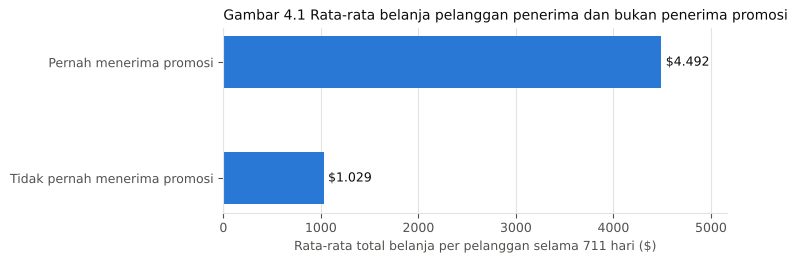

In [ ]:
total = trx.groupby("household_key").SALES_VALUE.sum()
jml = penerima.groupby("household_key").CAMPAIGN.nunique().reindex(total.index).fillna(0)
belanja_penerima, belanja_bukan = total[jml > 0].mean(), total[jml == 0].mean()

print(f"Pelanggan pernah menerima promosi : {(jml > 0).sum():,} ({100 * (jml > 0).mean():.1f}%)")
print(f"Rata-rata belanja penerima        : ${belanja_penerima:,.0f}")
print(f"Rata-rata belanja bukan penerima  : ${belanja_bukan:,.0f} ({belanja_penerima / belanja_bukan:.1f} kali lebih rendah)")
print(f"Korelasi jumlah promosi–belanja   : {np.corrcoef(jml, total)[0, 1]:.2f}")

fig, ax = plt.subplots(figsize=(6.5, 2.4)); gaya(ax)
label = ["Pernah menerima promosi", "Tidak pernah menerima promosi"]
nilai = [belanja_penerima, belanja_bukan]
ax.barh(label, nilai, height=0.45, color=WARNA["biru"])
for i, v in enumerate(nilai):
    ax.text(v + max(nilai) * 0.01, i, f"${rp(v, 0)}", va="center", fontsize=9, color=WARNA["teks"])
ax.invert_yaxis(); ax.set_xlim(0, max(nilai) * 1.15)
ax.set_xlabel("Rata-rata total belanja per pelanggan selama 711 hari ($)", fontsize=9, color=WARNA["teks2"])
ax.set_title("Gambar 4.1 Rata-rata belanja pelanggan penerima dan bukan penerima promosi",
             fontsize=10, color=WARNA["teks"], loc="left")
simpan_gambar(fig, "gambar_4_1_pola_pemberian_promosi.png")

## 5. Fungsi perhitungan (Bab 3.3–3.5)

### 5.1 Karakteristik pelanggan sebelum promosi
Enam karakteristik untuk menyesuaikan kelompok pembanding: total belanja (*monetary*), jumlah kunjungan (*frequency*), hari sejak kunjungan terakhir (*recency*), belanja 56 hari terakhir, proporsi diskon (kecenderungan memakai diskon), dan jumlah promosi yang pernah diterima. Variabel belanja dan kunjungan memakai transformasi logaritma.

In [ ]:
KARAKTERISTIK = ["log_belanja_total", "log_jumlah_kunjungan", "hari_sejak_kunjungan",
                 "log_belanja_56hari", "proporsi_diskon", "jumlah_promosi_lalu"]

def karakteristik_pelanggan(cutoff):
    """Karakteristik pelanggan dari transaksi sebelum hari `cutoff`."""
    sebelum = trx[trx.DAY < cutoff]
    g = sebelum.groupby("household_key")
    f = pd.DataFrame({"belanja_total": g.SALES_VALUE.sum(),
                      "jumlah_kunjungan": g.BASKET_ID.nunique(),
                      "kunjungan_terakhir": g.DAY.max(),
                      "kotor": g.PENJUALAN_KOTOR.sum(),
                      "diskon": g.DISKON.sum()})
    f["belanja_56hari"] = sebelum[sebelum.DAY >= cutoff - 56].groupby("household_key").SALES_VALUE.sum()
    f["belanja_56hari"] = f["belanja_56hari"].fillna(0)
    f["hari_sejak_kunjungan"] = cutoff - f.kunjungan_terakhir
    f["proporsi_diskon"] = (f.diskon / f.kotor.replace(0, np.nan)).fillna(0)
    lalu = penerima.merge(promosi[["CAMPAIGN", "START_DAY"]], on="CAMPAIGN")
    lalu = lalu[lalu.START_DAY < cutoff].groupby("household_key").CAMPAIGN.nunique()
    f["jumlah_promosi_lalu"] = lalu.reindex(f.index).fillna(0)
    f["log_belanja_total"] = np.log1p(f.belanja_total.clip(lower=0))
    f["log_jumlah_kunjungan"] = np.log1p(f.jumlah_kunjungan)
    f["log_belanja_56hari"] = np.log1p(f.belanja_56hari.clip(lower=0))
    return f

def jumlah_per_pelanggan(hari_awal, hari_akhir, kolom, index):
    w = trx[(trx.DAY >= hari_awal) & (trx.DAY <= hari_akhir)]
    return w.groupby("household_key")[kolom].sum().reindex(index).fillna(0).values

### 5.2 Cara hitung terkoreksi: DiD *doubly robust* dengan bobot *entropy balancing*

1. **Langkah 1 – Entropy balancing.** Kelompok pembanding diberi bobot agar rata-rata keenam karakteristiknya sama persis dengan pelanggan penerima, sedekat mungkin dengan bobot seragam.
2. **Langkah 2 – Perubahan belanja (DiD).** ΔY = belanja selama promosi − belanja periode sebelum.
3. **Langkah 3 – Koreksi regresi.** Regresi linear berbobot ΔY terhadap karakteristik pada kelompok pembanding, lalu

$$\text{Efek} = \frac{1}{n_{\text{penerima}}}\sum_{\text{penerima}}[\Delta Y_i - m(X_i)] - \sum_{\text{pembanding}} w_j[\Delta Y_j - m(X_j)]$$

**Jumlah pembanding efektif** = 1 / Σ w², dan **standard error** dihitung dengan *bootstrap* per pelanggan.

In [ ]:
def bobot_entropy_balancing(X_pembanding, rata2_penerima):
    """Langkah 1: bobot pembanding (jumlah = 1) yang menyamakan rata-rata karakteristik."""
    Z = X_pembanding - rata2_penerima
    def fungsi(l):
        a = Z @ l; m = a.max(); e = np.exp(a - m)
        return m + np.log(e.sum()), (e[:, None] * Z).sum(0) / e.sum()
    hasil = minimize(fungsi, np.zeros(Z.shape[1]), jac=True, method="BFGS",
                     options={"maxiter": 2000, "gtol": 1e-10})
    a = Z @ hasil.x
    w = np.exp(a - a.max()); w = w / w.sum()
    return w if np.all(np.isfinite(w)) else None

def efek_terkoreksi(X, D, dY):
    """Langkah 1–3. X = karakteristik, D = 1 penerima / 0 pembanding, dY = perubahan belanja."""
    sd = X.std(0)
    Xs = (X - X.mean(0)) / np.where(sd == 0, 1, sd)
    Xt, Xc = Xs[D == 1], Xs[D == 0]
    w = bobot_entropy_balancing(Xc, Xt.mean(0))
    if w is None:
        return np.nan, None
    reg = LinearRegression().fit(Xc, dY[D == 0], sample_weight=w)
    efek = (dY[D == 1] - reg.predict(Xt)).mean() - np.sum(w * (dY[D == 0] - reg.predict(Xc)))
    return efek, w

def standard_error_bootstrap(X, D, dY, rng):
    idx_t, idx_c = np.where(D == 1)[0], np.where(D == 0)[0]
    hasil = []
    for _ in range(ULANGAN_BOOTSTRAP):
        ii = np.concatenate([rng.choice(idx_t, len(idx_t)), rng.choice(idx_c, len(idx_c))])
        hasil.append(efek_terkoreksi(X[ii], D[ii], dY[ii])[0])
    hasil = np.array(hasil); hasil = hasil[np.isfinite(hasil)]
    return float(np.std(hasil, ddof=1)) if len(hasil) > min(20, ULANGAN_BOOTSTRAP // 2) else np.nan

### 5.3 Perhitungan satu program promosi (Bab 3.4)

- **Periode promosi:** hari mulai *s* sampai hari akhir *e*; **periode sebelum:** *L* hari tepat sebelum *s* (*L* = durasi promosi).
- **Kelompok pembanding:** pelanggan yang tidak menerima promosi ini maupun promosi lain yang berjalan bersamaan.
- **Karakteristik** diukur sebelum periode sebelum dimulai (hari *s* − *L*).
- **Cara konvensional:** rata-rata belanja penerima − rata-rata belanja pembanding selama periode promosi.

In [ ]:
def hitung_promosi(no):
    info = promosi[promosi.CAMPAIGN == no].iloc[0]
    s, e = int(info.START_DAY), int(info.END_DAY)
    L = e - s + 1
    bersamaan = promosi[(promosi.START_DAY <= e) & (promosi.END_DAY >= s)].CAMPAIGN.tolist()
    set_penerima = set(penerima[penerima.CAMPAIGN == no].household_key)
    set_sibuk = set(penerima[penerima.CAMPAIGN.isin(bersamaan)].household_key)

    f = karakteristik_pelanggan(s - L)
    f = f[f.index.isin(set_penerima) | ~f.index.isin(set_sibuk)].copy()
    D = f.index.isin(set_penerima).astype(int)

    selama = jumlah_per_pelanggan(s, e, "SALES_VALUE", f.index)
    sebelum = jumlah_per_pelanggan(s - L, s - 1, "SALES_VALUE", f.index)
    hasil = dict(promosi=no, tipe=info.DESCRIPTION.replace("Type", ""), hari_mulai=s, hari_akhir=e,
                 durasi=L, pelanggan_penerima=int(D.sum()), kelompok_pembanding=int((1 - D).sum()),
                 belanja_sebelum_penerima=sebelum[D == 1].mean(),
                 belanja_selama_penerima=selama[D == 1].mean(),
                 belanja_sebelum_pembanding=sebelum[D == 0].mean(),
                 belanja_selama_pembanding=selama[D == 0].mean(),
                 konvensional=selama[D == 1].mean() - selama[D == 0].mean())   # cara konvensional
    if D.sum() < MIN_PENERIMA:
        return hasil
    X = f[KARAKTERISTIK].values
    dY = selama - sebelum
    efek, w = efek_terkoreksi(X, D, dY)
    if w is None or not np.isfinite(efek):
        return hasil   # tidak ada pembanding yang mirip (mis. promosi #3)

    rng = np.random.default_rng(SEED + no)
    se = standard_error_bootstrap(X, D, dY, rng)
    d_diskon = (jumlah_per_pelanggan(s, e, "DISKON", f.index)
                - jumlah_per_pelanggan(s - L, s - 1, "DISKON", f.index))
    efek_diskon, _ = efek_terkoreksi(X, D, d_diskon)
    se_diskon = standard_error_bootstrap(X, D, d_diskon, rng)
    hasil.update(jumlah_pembanding_efektif=1 / np.sum(w ** 2),
                 setelah_koreksi=efek, se=se, ik95_bawah=efek - 1.96 * se, ik95_atas=efek + 1.96 * se,
                 tambahan_diskon=efek_diskon, se_diskon=se_diskon,
                 belanja_sebelum_pembanding_dibobot=np.sum(w * sebelum[D == 0]),
                 belanja_selama_pembanding_dibobot=np.sum(w * selama[D == 0]))
    return hasil

def gabungkan(efek, se):
    """Rata-rata pembobotan (bobot = 1/SE²) dan statistik Q."""
    w = 1 / se ** 2
    m = np.sum(w * efek) / np.sum(w); s = np.sqrt(1 / np.sum(w))
    Q = np.sum(w * (efek - m) ** 2)
    return m, s, Q, len(efek) - 1, chi2.sf(Q, len(efek) - 1)

## 6. Hasil 30 program promosi (Bab 4.4)

Sel ini menjalankan perhitungan untuk seluruh 30 promosi, dan merupakan bagian paling lama (sekitar 15–30 menit dengan 1.000 ulangan bootstrap).

In [ ]:
mulai = time.time()
baris = []
for no in sorted(promosi.CAMPAIGN):
    t0 = time.time()
    h = hitung_promosi(no)
    baris.append(h)
    txt = f"{h['setelah_koreksi']:8.1f} (SE {h['se']:.1f})" if "setelah_koreksi" in h else "tidak dapat dihitung"
    print(f"Promosi #{no:2d}: konvensional {h['konvensional']:7.1f} | setelah koreksi {txt}  [{time.time() - t0:.0f} detik]")
df = pd.DataFrame(baris)
print(f"\nSelesai dalam {(time.time() - mulai) / 60:.1f} menit.")

Promosi # 1: konvensional   138.3 | setelah koreksi    -17.3 (SE 55.9)  [192 detik]


Promosi # 2: konvensional   111.2 | setelah koreksi     -9.0 (SE 23.8)  [14 detik]


Promosi # 3: konvensional   581.8 | setelah koreksi tidak dapat dihitung  [1 detik]


Promosi # 4: konvensional   203.2 | setelah koreksi     42.4 (SE 22.8)  [13 detik]


Promosi # 5: konvensional   297.8 | setelah koreksi     16.1 (SE 22.0)  [14 detik]


...

Promosi #26: konvensional   142.2 | setelah koreksi     18.7 (SE 14.5)  [12 detik]


Promosi #27: konvensional   382.9 | setelah koreksi    -48.1 (SE 101.2)  [55 detik]


Promosi #28: konvensional   391.4 | setelah koreksi     22.6 (SE 105.5)  [13 detik]


Promosi #29: konvensional   194.8 | setelah koreksi     34.6 (SE 22.3)  [14 detik]


Promosi #30: konvensional   151.0 | setelah koreksi      2.6 (SE 28.9)  [12 detik]

Selesai dalam 25.7 menit.


### 6.1 Ilustrasi perhitungan promosi #8 (Bab 4.3, Tabel 4.1, Gambar 4.2)

Konvensional    : 392.9 − 124.4 = 268.5
Setelah koreksi : 0.4


Kelompok,Belanja periode sebelum,Belanja selama promosi,Perubahan
Pelanggan penerima promosi,396.8,392.9,-3.9
Kelompok pembanding tanpa bobot,114.8,124.4,9.7
Kelompok pembanding setelah entropy balancing,475.8,471.6,-4.3


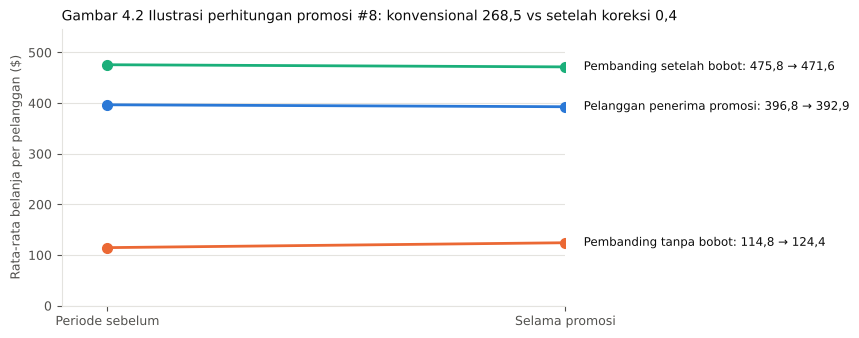

In [ ]:
il = df[df.promosi == PROMOSI_ILUSTRASI].iloc[0]
tabel_41 = pd.DataFrame({
    "Kelompok": ["Pelanggan penerima promosi", "Kelompok pembanding tanpa bobot",
                 "Kelompok pembanding setelah entropy balancing"],
    "Belanja periode sebelum": [il.belanja_sebelum_penerima, il.belanja_sebelum_pembanding,
                                il.belanja_sebelum_pembanding_dibobot],
    "Belanja selama promosi": [il.belanja_selama_penerima, il.belanja_selama_pembanding,
                               il.belanja_selama_pembanding_dibobot]})
tabel_41["Perubahan"] = tabel_41["Belanja selama promosi"] - tabel_41["Belanja periode sebelum"]
print(f"Konvensional    : {il.belanja_selama_penerima:.1f} − {il.belanja_selama_pembanding:.1f} = {il.konvensional:.1f}")
print(f"Setelah koreksi : {il.setelah_koreksi:.1f}")
display(tabel_41.style.format(precision=1).hide(axis="index"))

seri = [("Pelanggan penerima promosi", il.belanja_sebelum_penerima, il.belanja_selama_penerima, WARNA["biru"]),
        ("Pembanding tanpa bobot", il.belanja_sebelum_pembanding, il.belanja_selama_pembanding, WARNA["oranye"]),
        ("Pembanding setelah bobot", il.belanja_sebelum_pembanding_dibobot, il.belanja_selama_pembanding_dibobot, WARNA["aqua"])]
fig, ax = plt.subplots(figsize=(6.5, 3.6)); gaya(ax)
ax.grid(axis="x", visible=False); ax.grid(axis="y", color=WARNA["grid"], linewidth=0.8)
for nama, a, b, w in seri:
    ax.plot([0, 1], [a, b], color=w, linewidth=2, marker="o", markersize=7)
    ax.text(1.04, b, f"{nama}: {rp(a)} → {rp(b)}", va="center", fontsize=8.5, color=WARNA["teks"])
ax.set_xticks([0, 1], ["Periode sebelum", "Selama promosi"]); ax.set_xlim(-0.1, 1.0)
ax.set_ylim(0, max(max(x[1], x[2]) for x in seri) * 1.15)
ax.set_ylabel("Rata-rata belanja per pelanggan ($)", fontsize=9, color=WARNA["teks2"])
ax.set_title(f"Gambar 4.2 Ilustrasi perhitungan promosi #{PROMOSI_ILUSTRASI}: konvensional "
             f"{rp(il.konvensional)} vs setelah koreksi {rp(il.setelah_koreksi)}", fontsize=10, color=WARNA["teks"], loc="left")
simpan_gambar(fig, "gambar_4_2_ilustrasi_promosi_8.png")

### 6.2 Tabel 4.2 dan Gambar 4.3

In [ ]:
kolom_42 = {"promosi": "Promosi", "tipe": "Tipe", "durasi": "Durasi (hari)",
            "pelanggan_penerima": "Pelanggan penerima", "kelompok_pembanding": "Kelompok pembanding",
            "jumlah_pembanding_efektif": "Jumlah pembanding efektif", "konvensional": "Konvensional",
            "setelah_koreksi": "Setelah koreksi", "se": "SE",
            "ik95_bawah": "IK 95% bawah", "ik95_atas": "IK 95% atas"}
tabel_42 = df.reindex(columns=list(kolom_42)).rename(columns=kolom_42)
ok = df.dropna(subset=["setelah_koreksi", "se"])
print(f"Konvensional positif           : {(df.konvensional > 0).sum()} dari {len(df)} promosi "
      f"(min {df.konvensional.min():.1f}, maks {df.konvensional.max():.1f}, median {df.konvensional.median():.1f})")
print(f"Dapat dihitung setelah koreksi : {len(ok)} promosi")
print(f"Signifikan positif             : {list(ok[ok.ik95_bawah > 0].promosi)}")
display(tabel_42.style.format(precision=1, na_rep="—").hide(axis="index"))

Konvensional positif           : 30 dari 30 promosi (min 111.2, maks 833.5, median 305.4)
Dapat dihitung setelah koreksi : 29 promosi
Signifikan positif             : [21, 22]


Promosi,Tipe,Durasi (hari),Pelanggan penerima,Kelompok pembanding,Jumlah pembanding efektif,Konvensional,Setelah koreksi,SE,IK 95% bawah,IK 95% atas
1,B,38,13,1947,27.7,138.3,-17.3,55.9,-127.0,92.3
2,B,33,48,1947,252.9,111.2,-9.0,23.8,-55.6,37.7
3,C,57,12,1281,—,581.8,—,—,—,—
4,B,33,81,2049,532.0,203.2,42.4,22.8,-2.3,87.1
5,B,35,166,2049,335.7,297.8,16.1,22.0,-27.0,59.2
6,C,33,65,1381,38.3,401.4,6.2,43.2,-78.5,90.9
7,B,35,198,1381,93.2,281.7,6.8,23.8,-39.8,53.3
8,A,49,1076,1356,177.5,268.5,0.4,22.4,-43.5,44.3
9,B,33,176,1362,129.6,183.8,-24.9,26.3,-76.5,26.7
10,B,33,123,1948,255.7,239.1,-14.9,22.7,-59.4,29.6


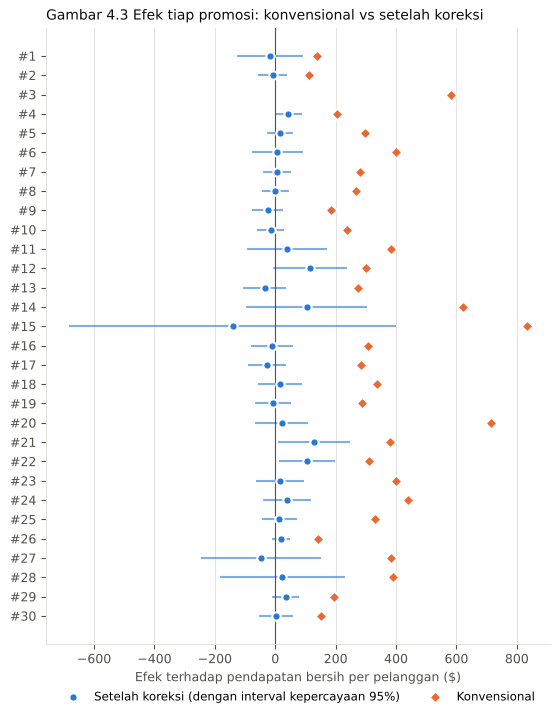

In [ ]:
d = df.sort_values("promosi", ascending=False).reset_index(drop=True)
y = np.arange(len(d)); m_ok = d.setelah_koreksi.notna()
fig, ax = plt.subplots(figsize=(6.5, 8)); gaya(ax)
ax.hlines(y[m_ok], d.ik95_bawah[m_ok], d.ik95_atas[m_ok], color=WARNA["biru"], linewidth=1.5, alpha=0.6)
ax.scatter(d.setelah_koreksi[m_ok], y[m_ok], s=36, color=WARNA["biru"], zorder=3, edgecolor=WARNA["latar"],
           linewidth=1.5, label="Setelah koreksi (dengan interval kepercayaan 95%)")
ax.scatter(d.konvensional, y, s=36, color=WARNA["oranye"], zorder=3, marker="D", edgecolor=WARNA["latar"],
           linewidth=1.5, label="Konvensional")
ax.axvline(0, color=WARNA["teks2"], linewidth=0.8)
ax.set_yticks(y, [f"#{n}" for n in d.promosi])
ax.set_xlabel("Efek terhadap pendapatan bersih per pelanggan ($)", fontsize=9, color=WARNA["teks2"])
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.06), ncol=2, frameon=False, fontsize=8.5)
ax.set_title("Gambar 4.3 Efek tiap promosi: konvensional vs setelah koreksi", fontsize=10, color=WARNA["teks"], loc="left")
simpan_gambar(fig, "gambar_4_3_konvensional_vs_koreksi.png")

## 7. Efek rata-rata gabungan (Bab 4.5, Gambar 4.4)

Efek setelah koreksi (gabungan 29 promosi): $10.9 (SE 5.7; IK 95% -0.4 s.d. 22.1)
Rata-rata konvensional                     : $330.8
Efek setelah koreksi / konvensional        : 3.3%
Statistik Q                                : 24.3 (derajat bebas 28, p = 0.67)


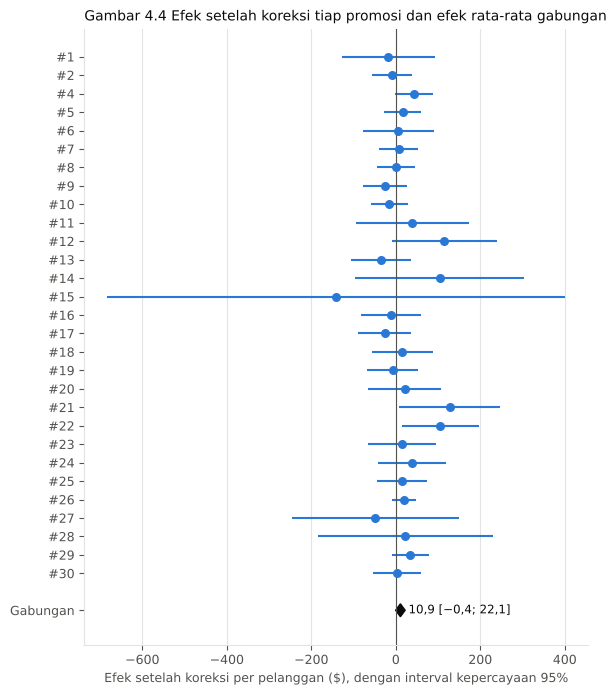

In [ ]:
m, s, Q, dof, p = gabungkan(ok.setelah_koreksi.values, ok.se.values)
konv = ok.konvensional.mean()
print(f"Efek setelah koreksi (gabungan {len(ok)} promosi): ${m:.1f} (SE {s:.1f}; IK 95% {m - 1.96 * s:.1f} s.d. {m + 1.96 * s:.1f})")
print(f"Rata-rata konvensional                     : ${konv:.1f}")
print(f"Efek setelah koreksi / konvensional        : {100 * m / konv:.1f}%")
print(f"Statistik Q                                : {Q:.1f} (derajat bebas {dof}, p = {p:.2f})")

d2 = d[m_ok].reset_index(drop=True); y2 = np.arange(len(d2)) + 2
fig, ax = plt.subplots(figsize=(6.5, 8)); gaya(ax)
ax.hlines(y2, d2.ik95_bawah, d2.ik95_atas, color=WARNA["biru"], linewidth=1.5)
ax.scatter(d2.setelah_koreksi, y2, s=30, color=WARNA["biru"], zorder=3)
ax.fill([m - 1.96 * s, m, m + 1.96 * s, m], [0, 0.35, 0, -0.35], color=WARNA["teks"])
ax.axvline(0, color=WARNA["teks2"], linewidth=0.8)
ax.set_yticks(list(y2) + [0], [f"#{n}" for n in d2.promosi] + ["Gabungan"])
ax.text(m + 1.96 * s + 8, 0, f"{rp(m)} [{rp(m - 1.96 * s)}; {rp(m + 1.96 * s)}]", va="center", fontsize=8.5, color=WARNA["teks"])
ax.set_xlabel("Efek setelah koreksi per pelanggan ($), dengan interval kepercayaan 95%", fontsize=9, color=WARNA["teks2"])
ax.set_title("Gambar 4.4 Efek setelah koreksi tiap promosi dan efek rata-rata gabungan", fontsize=10, color=WARNA["teks"], loc="left")
simpan_gambar(fig, "gambar_4_4_efek_setelah_koreksi.png")

## 8. Tambahan biaya diskon (Bab 4.6, Tabel 4.3, Gambar 4.5)

Tambahan diskon perusahaan (gabungan): $5.04 (SE 1.06; IK 95% 2.96 s.d. 7.12)
Efek terhadap penjualan kotor        : $15.9; porsi diskon 32%


Promosi,Perubahan pendapatan bersih,Tambahan diskon perusahaan,SE
1,-17.3,14.4,11.6
2,-9.0,4.3,6.1
4,42.4,6.2,4.1
5,16.1,4.7,4.2
6,6.2,5.4,7.5
7,6.8,4.3,4.7
8,0.4,0.3,4.9
9,-24.9,-5.7,5.4
10,-14.9,-2.0,4.3
11,39.1,4.4,9.8


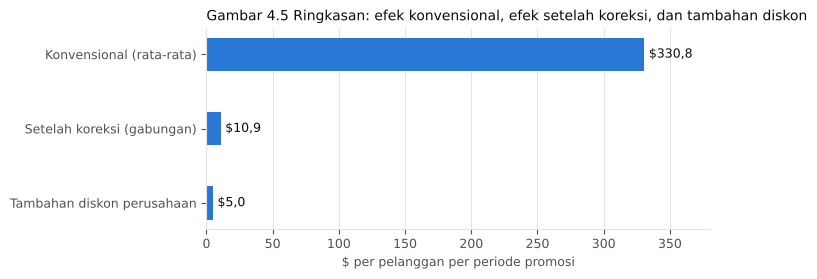

In [ ]:
okd = ok.dropna(subset=["se_diskon"])
md_, sd_, *_ = gabungkan(okd.tambahan_diskon.values, okd.se_diskon.values)
print(f"Tambahan diskon perusahaan (gabungan): ${md_:.2f} (SE {sd_:.2f}; IK 95% {md_ - 1.96 * sd_:.2f} s.d. {md_ + 1.96 * sd_:.2f})")
print(f"Efek terhadap penjualan kotor        : ${m + md_:.1f}; porsi diskon {100 * md_ / (m + md_):.0f}%")

tabel_43 = ok[["promosi", "setelah_koreksi", "tambahan_diskon", "se_diskon"]].rename(columns={
    "promosi": "Promosi", "setelah_koreksi": "Perubahan pendapatan bersih",
    "tambahan_diskon": "Tambahan diskon perusahaan", "se_diskon": "SE"})
display(tabel_43.style.format(precision=1).hide(axis="index"))

fig, ax = plt.subplots(figsize=(6.5, 2.6)); gaya(ax)
label = ["Konvensional (rata-rata)", "Setelah koreksi (gabungan)", "Tambahan diskon perusahaan"]
nilai = [konv, m, md_]
ax.barh(label, nilai, height=0.45, color=WARNA["biru"])
for i, v in enumerate(nilai):
    ax.text(v + max(nilai) * 0.01, i, f"${rp(v)}", va="center", fontsize=9, color=WARNA["teks"])
ax.invert_yaxis(); ax.set_xlim(0, max(nilai) * 1.15)
ax.set_xlabel("$ per pelanggan per periode promosi", fontsize=9, color=WARNA["teks2"])
ax.set_title("Gambar 4.5 Ringkasan: efek konvensional, efek setelah koreksi, dan tambahan diskon", fontsize=10, color=WARNA["teks"], loc="left")
simpan_gambar(fig, "gambar_4_5_ringkasan.png")

## 9. Menyimpan hasil

In [ ]:
kolom = ["promosi", "tipe", "durasi", "pelanggan_penerima", "kelompok_pembanding", "jumlah_pembanding_efektif",
         "konvensional", "setelah_koreksi", "se", "ik95_bawah", "ik95_atas", "tambahan_diskon", "se_diskon"]
tabel = df.reindex(columns=kolom).round(2)
tabel.to_csv(os.path.join(FOLDER_HASIL, "tabel_hasil_per_promosi.csv"), index=False)
tabel.to_excel(os.path.join(FOLDER_HASIL, "tabel_hasil_per_promosi.xlsx"), index=False)
print("Tersimpan di folder", FOLDER_HASIL)
for root, _, files in os.walk(FOLDER_HASIL):
    for f in sorted(files):
        print(" -", os.path.join(root, f))

Tersimpan di folder hasil
 - hasil/tabel_hasil_per_promosi.csv
 - hasil/tabel_hasil_per_promosi.xlsx
 - hasil/gambar/gambar_4_1_pola_pemberian_promosi.png
 - hasil/gambar/gambar_4_2_ilustrasi_promosi_8.png
 - hasil/gambar/gambar_4_3_konvensional_vs_koreksi.png
 - hasil/gambar/gambar_4_4_efek_setelah_koreksi.png
 - hasil/gambar/gambar_4_5_ringkasan.png
